# Graph Construction: What's Actually Happening

This notebook answers precisely: **why are some real covalent bonds absent from the SOTA graph?**

The short answer: the SOTA graph does **not** use `molecule_graph.graph.edges()` for bond node creation. It uses the `bonds` column in the PKL, which is the **QTAIM bond critical point list** — a fundamentally different thing.

Steps:
1. Real molecular graph from `molecule_graph.graph.edges()`
2. What the `bonds` column actually contains vs real bonds
3. How `HeteroCompleteGraphFromMolWrapper` builds the HeteroData
4. Feature vectors per experiment (topo / topo_elf / topo_qtaim)
5. SOTA graph vs real bonds comparison
6. **ELF CP graph** from `build_hetero_critical_from_json` — topology, nodes, edges, tensors
7. All three side by side

## Setup

In [3]:
import json, ast, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io, torch

ATOM_COLOR = {"C":"#2C2C2A","N":"#1E5FA5","O":"#C94F2A","H":"#9E9C96","F":"#1D9E75"}
BOND_COLOR  = "#C97B1A"
print("Imports OK")


Imports OK


In [4]:
BASE      = "/lustre/fsn1/projects/rech/ihj/urb54jd"
PKL_TRAIN = f"{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/train_43k.pkl"
PKL_VAL   = f"{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/val_43k.pkl"
PKL_TEST  = f"{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/test_43k.pkl"
ELF_CSV   = f"{BASE}/gnn/control_and_critical_points_GNNs/data/qm9_43k_clean_with_val.csv"
JSON_DIR  = f"{BASE}/gnn/control_and_critical_points_GNNs/data/criticalpoints_jsonfiles"
print("Paths set")


Paths set


In [5]:
print("Loading PKL...")
sota_df = pd.concat([pd.read_pickle(PKL_TRAIN),
                     pd.read_pickle(PKL_VAL),
                     pd.read_pickle(PKL_TEST)], ignore_index=True)
sota_df["gdb_num"] = sota_df["names"].str.extract(r"gdb_(\d+)\.xyz").astype(int)
elf_df  = pd.read_csv(ELF_CSV)
print(f"SOTA PKL: {len(sota_df)} rows")

# ── Bond-related columns ─────────────────────────────────────────────────────
print("\nBond-related columns in PKL:")
for c in [c for c in sota_df.columns if "bond" in c.lower()]:
    print(f"  {c}")


Loading PKL...
SOTA PKL: 43476 rows

Bond-related columns in PKL:
  bonds
  extra_feat_bond_Lagrangian_K
  extra_feat_bond_Hamiltonian_K
  extra_feat_bond_e_density
  extra_feat_bond_lap_e_density
  extra_feat_bond_e_loc_func
  extra_feat_bond_ave_loc_ion_E
  extra_feat_bond_delta_g_promolecular
  extra_feat_bond_delta_g_hirsh
  extra_feat_bond_esp_nuc
  extra_feat_bond_esp_e
  extra_feat_bond_esp_total
  extra_feat_bond_grad_norm
  extra_feat_bond_lap_norm
  extra_feat_bond_eig_hess
  extra_feat_bond_det_hessian
  extra_feat_bond_ellip_e_dens
  extra_feat_bond_eta
  extra_feat_bond_indices_qtaim
  bonds_original
  extra_feat_bond_energy_density
  extra_feat_bond_density_beta
  extra_feat_bond_density_alpha
  extra_feat_bond_spin_density
  extra_feat_bond_lol


In [6]:
def _parse_bonds(raw):
    s = str(raw).strip()
    if s.startswith("[["): s = s[1:-1]
    try:    return [(int(a), int(b)) for a,b in ast.literal_eval(s)]
    except: return []

def _parse_array(raw):
    s = str(raw).strip()
    if s.startswith("[[") and s.endswith("]]"): s = s[1:-1]
    try:    return np.array(ast.literal_eval(s), dtype=float)
    except: return np.array([])

BOND_QTAIM_COLS = [
    "extra_feat_bond_Hamiltonian_K","extra_feat_bond_e_density",
    "extra_feat_bond_lap_e_density","extra_feat_bond_e_loc_func",
    "extra_feat_bond_ave_loc_ion_E","extra_feat_bond_delta_g_promolecular",
    "extra_feat_bond_delta_g_hirsh","extra_feat_bond_esp_nuc",
    "extra_feat_bond_esp_e","extra_feat_bond_esp_total",
    "extra_feat_bond_grad_norm","extra_feat_bond_lap_norm",
    "extra_feat_bond_eig_hess","extra_feat_bond_det_hessian",
    "extra_feat_bond_ellip_e_dens","extra_feat_bond_eta",
    "extra_feat_bond_energy_density","extra_feat_bond_lol",
    "extra_feat_bond_Lagrangian_K",
]

ATOM_COLOR = {"C":"#2C2C2A","N":"#1E5FA5","O":"#C94F2A","H":"#9E9C96","F":"#1D9E75"}
CP_BOND_C  = "#C97B1A"
CP_LONE_C  = "#7B1FA2"
CP_CORE_C  = "#37474F"

def get_rdkit_pos(smiles, n_atoms):
    """
    Get RDKit 2D positions — same coords used to render the structure drawing.
    Uses mol.GetConformer().GetAtomPosition(i) after Compute2DCoords.
    This makes the graph layout identical to the chemical structure diagram.
    """
    from rdkit import Chem
    from rdkit.Chem import AllChem
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)          # explicit H so indices match pymatgen
    AllChem.Compute2DCoords(mol)
    pos = {}
    for i in range(n_atoms):
        p = mol.GetConformer().GetAtomPosition(i)
        pos[i] = (p.x, p.y)
    return pos, mol

def draw_mol_structure(smiles, ax, n_atoms, title="Molecular Structure"):
    """Left panel: RDKit PNG image — same as GNN_representation.ipynb."""
    from rdkit import Chem
    from rdkit.Chem import AllChem, Draw
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    for a in mol.GetAtoms():
        a.SetAtomMapNum(a.GetIdx())
    img = Draw.MolToImage(mol, size=(400, 400))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

def draw_graph_on_rdkit_coords(ax, pos, syms, n_atoms, edges,
                                edge_colors=None, edge_styles=None,
                                bond_nodes=None, bond_node_color="#C97B1A",
                                bond_node_marker="s",
                                cp_nodes=None,
                                title="Graph Representation"):
    """
    Right panel: networkx-style graph drawn at RDKit 2D coordinates.
    Looks like GNN_representation.ipynb Graph Representation panel.
    Uses real chemical geometry instead of spring layout.
    """
    import networkx as nx
    import matplotlib.pyplot as plt

    G = nx.Graph()
    for i in range(n_atoms):
        G.add_node(i)
    for e in edges:
        G.add_edge(e[0], e[1])

    # Draw edges
    for k, (i, j) in enumerate(edges):
        ec = edge_colors[k] if edge_colors else "#888888"
        es = edge_styles[k] if edge_styles else "-"
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                color=ec, lw=1.8, ls=es, zorder=1)

    # Draw bond/CP nodes at midpoints if requested
    if bond_nodes:
        for (i, j), color, marker in bond_nodes:
            mid = ((pos[i][0]+pos[j][0])/2, (pos[i][1]+pos[j][1])/2)
            ax.plot(*mid, marker, color=color, ms=9, zorder=4,
                    markeredgecolor="white", markeredgewidth=0.5)

    # Draw atom nodes
    node_colors = [ATOM_COLOR.get(syms[i], "#888") for i in range(n_atoms)]
    node_sizes  = [400 if syms[i] != "H" else 150 for i in range(n_atoms)]
    xs = [pos[i][0] for i in range(n_atoms)]
    ys = [pos[i][1] for i in range(n_atoms)]
    ax.scatter(xs, ys, c=node_colors, s=node_sizes,
               zorder=3, edgecolors="white", linewidths=0.7)
    for i in range(n_atoms):
        ax.annotate(f"{i}\n{syms[i]}", (pos[i][0], pos[i][1]),
                    ha="center", va="center", fontsize=5,
                    color="white", fontweight="bold", zorder=5)

    # Draw lone/core CP nodes if provided
    if cp_nodes:
        for (px, py), color, marker in cp_nodes:
            ax.plot(px, py, marker, color=color, ms=7, zorder=4,
                    markeredgecolor="white", markeredgewidth=0.4)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=11)

print("Helpers loaded — using RDKit 2D coordinates for graph layout")


Helpers loaded — using RDKit 2D coordinates for graph layout


## Pick a molecule

In [7]:
MOL_ID = "dsgdb9nsd_101598"   # 

elf_row  = elf_df[elf_df["ID"]==MOL_ID].iloc[0]
gdb_num  = int(elf_row["GDB_Index"])
smiles   = str(elf_row.get("canonical_smiles", elf_row.get("SMILES","")))
sota_row = sota_df[sota_df["gdb_num"]==gdb_num].iloc[0]

mol_pm   = sota_row["molecule"]
mol_g    = sota_row["molecule_graph"]
n_atoms  = len(mol_pm.sites)
syms     = [str(s.species.elements[0].symbol) for s in mol_pm.sites]

# ── THREE different bond lists ────────────────────────────────────────────────
# 1) molecule_graph.graph.edges() — full real covalent connectivity
mg_edges = sorted({(min(u,v),max(u,v)) for u,v in mol_g.graph.edges()})

# 2) "bonds" column in PKL — what HeteroCompleteGraphFromMolWrapper uses
#    when bond_key="bonds"  (the QTAIM bond list, NOT full connectivity)
raw_bonds = sota_row["bonds"]
if isinstance(raw_bonds[0], (list, tuple)): raw_bonds = raw_bonds[0]
bonds_col = sorted({(min(a,b),max(a,b)) for a,b in raw_bonds if a!=b})

# 3) extra_feat_bond_indices_qtaim — parallel index for feature arrays
qtaim_idx = _parse_bonds(sota_row["extra_feat_bond_indices_qtaim"])
qtaim_set = {(min(a,b),max(a,b)) for a,b in qtaim_idx if a!=b}

print(f"Molecule : {MOL_ID}  ({n_atoms} atoms)  SMILES: {smiles}")
print(f"\n1) molecule_graph.edges() : {len(mg_edges)} bonds  ← real covalent connectivity")
print(f"2) bonds column (PKL)     : {len(bonds_col)} bonds  ← used as graph topology")
print(f"3) qtaim index list       : {len(qtaim_set)} unique pairs  ← feature array index")
print(f"\nAre (1) and (2) the same? {set(mg_edges)==set(bonds_col)}")


Molecule : dsgdb9nsd_101598  (20 atoms)  SMILES: COC(=N)OC(C)CO

1) molecule_graph.edges() : 19 bonds  ← real covalent connectivity
2) bonds column (PKL)     : 15 bonds  ← used as graph topology
3) qtaim index list       : 15 unique pairs  ← feature array index

Are (1) and (2) the same? False


## bonds_original — what does it contain?

The PKL has both a `bonds` column and a `bonds_original` column. We know `bonds` = QTAIM BCP list. What is `bonds_original`? It is the `map_key` used by `get_bond_features()` in `descriptors.py` to look up which position in the feature arrays each bond sits at.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# bonds_original column — what is it?
# ══════════════════════════════════════════════════════════════════════════════

raw_orig = sota_row["bonds_original"]

# Unwrap if nested list
if isinstance(raw_orig, list):
    if len(raw_orig) == 1 and isinstance(raw_orig[0], list):
        raw_orig = raw_orig[0]
    bonds_original = [(int(a), int(b)) for a,b in raw_orig if a != b]
else:
    bonds_original = _parse_bonds(raw_orig)

bonds_orig_set = {(min(a,b), max(a,b)) for a,b in bonds_original}

mg  = set(mg_edges)
bnd = set(bonds_col)      # "bonds" col = QTAIM BCPs

print(f"bonds_original column: {len(bonds_orig_set)} unique pairs")
print(f"molecule_graph.edges(): {len(mg)} pairs")
print(f"bonds column (QTAIM):   {len(bnd)} pairs")
print()
print(f"bonds_original == molecule_graph.edges() ? {bonds_orig_set == mg}")
print(f"bonds_original == bonds col (QTAIM)?      {bonds_orig_set == bnd}")
print()

only_orig = sorted(bonds_orig_set - mg)
only_mg   = sorted(mg - bonds_orig_set)

print(f"In bonds_original but NOT in molecule_graph: {len(only_orig)}")
for i,j in only_orig:
    print(f"  ({i},{j}) {syms[i]}-{syms[j]}")

print(f"In molecule_graph but NOT in bonds_original: {len(only_mg)}")
for i,j in only_mg:
    print(f"  ({i},{j}) {syms[i]}-{syms[j]}")

print()
print("bonds_original raw values:")
for b in sorted(bonds_orig_set):
    i,j = b
    in_qtaim = b in bnd
    in_mg    = b in mg
    tag = []
    if in_mg:    tag.append("✓ real bond")
    if in_qtaim: tag.append("✓ in QTAIM")
    if not in_qtaim: tag.append("✗ NOT in QTAIM bonds col")
    print(f"  ({i:2d},{j:2d}) {syms[i]}-{syms[j]}  {'  '.join(tag)}")


bonds_original column: 15 unique pairs
molecule_graph.edges(): 19 pairs
bonds column (QTAIM):   15 pairs

bonds_original == molecule_graph.edges() ? False
bonds_original == bonds col (QTAIM)?      True

In bonds_original but NOT in molecule_graph: 5
  (1,14) O-H
  (1,19) O-H
  (4,7) O-C
  (6,7) C-C
  (7,13) C-H
In molecule_graph but NOT in bonds_original: 9
  (0,9) C-H
  (0,10) C-H
  (4,5) O-C
  (5,6) C-C
  (5,7) C-C
  (5,13) C-H
  (6,15) C-H
  (6,16) C-H
  (7,17) C-H

bonds_original raw values:
  ( 0, 1) C-O  ✓ real bond  ✓ in QTAIM
  ( 0,11) C-H  ✓ real bond  ✓ in QTAIM
  ( 1, 2) O-C  ✓ real bond  ✓ in QTAIM
  ( 1,14) O-H  ✓ in QTAIM
  ( 1,19) O-H  ✓ in QTAIM
  ( 2, 3) C-N  ✓ real bond  ✓ in QTAIM
  ( 2, 4) C-O  ✓ real bond  ✓ in QTAIM
  ( 3,12) N-H  ✓ real bond  ✓ in QTAIM
  ( 4, 7) O-C  ✓ in QTAIM
  ( 6, 7) C-C  ✓ in QTAIM
  ( 6,14) C-H  ✓ real bond  ✓ in QTAIM
  ( 7, 8) C-O  ✓ real bond  ✓ in QTAIM
  ( 7,13) C-H  ✓ in QTAIM
  ( 7,18) C-H  ✓ real bond  ✓ in QTAIM
  ( 8,19) O-H  ✓ r

In [9]:
# ── What bonds_original tells us about the SOTA graph construction ────────────
# 
# Now we know all four bond lists. Let's map out the full picture:
#   mg_edges       = molecule_graph.graph.edges() = real covalent bonds
#   bonds_original = ??? (we just found out above)
#   bonds_col      = "bonds" column = QTAIM BCP list = graph topology used
#   qtaim_set      = extra_feat_bond_indices_qtaim = feature array parallel index
#
# The critical question: which of these does HeteroCompleteGraphFromMolWrapper
# use to create bond nodes?
#
# From the config: bond_key="bonds", map_key="bonds_original" (or "bonds")
# get_bond_features() in descriptors.py:
#   bonds = row[bond_key]          ← creates bond nodes from THIS list
#   bond_index_map = row[map_key].index(bond)  ← looks up feature position
# ──────────────────────────────────────────────────────────────────────────────

mg  = set(mg_edges)
bnd = set(bonds_col)
orig = bonds_orig_set

print("="*65)
print("  COMPLETE PICTURE: all four bond lists")
print("="*65)
print()
print(f"  molecule_graph.edges()    : {len(mg):3d}  real covalent bonds")
print(f"  bonds_original column     : {len(orig):3d}  {'= real bonds' if orig==mg else '≠ real bonds — see below'}")
print(f"  bonds column (QTAIM)      : {len(bnd):3d}  QTAIM BCP list → used as bond_key")
print(f"  extra_feat_bond_indices   : {len(qtaim_set):3d}  parallel feature index")
print()
print(f"  bonds col == qtaim index? {bnd == qtaim_set}  (should be True — same list)")
print(f"  bonds_original == mg?     {orig == mg}")
print()

# Show which real bonds are absent from the QTAIM bond node list
missing_from_sota = sorted(mg - bnd)
phantom_in_sota   = sorted(bnd - mg)

print(f"  Real bonds with NO bond node in SOTA graph: {len(missing_from_sota)}")
for i,j in missing_from_sota:
    in_orig = (min(i,j),max(i,j)) in orig
    print(f"    ({i:2d},{j:2d}) {syms[i]}-{syms[j]}  [in bonds_original: {in_orig}]")

print()
print(f"  Phantom bond nodes (QTAIM-only, not real bonds): {len(phantom_in_sota)}")
for i,j in phantom_in_sota:
    in_orig = (min(i,j),max(i,j)) in orig
    print(f"    ({i:2d},{j:2d}) {syms[i]}-{syms[j]}  [in bonds_original: {in_orig}]")

print()
print("  CONCLUSION:")
print("  bonds_original is the map_key — used by get_bond_features() to")
print("  find which position in the feature array each bond sits at.")
print("  bond_key='bonds' (QTAIM list) creates the actual bond nodes.")
print("  This confirms: SOTA graph topology = QTAIM BCP topology, NOT")
print("  the full molecular bond graph.")
print("="*65)


  COMPLETE PICTURE: all four bond lists

  molecule_graph.edges()    :  19  real covalent bonds
  bonds_original column     :  15  ≠ real bonds — see below
  bonds column (QTAIM)      :  15  QTAIM BCP list → used as bond_key
  extra_feat_bond_indices   :  15  parallel feature index

  bonds col == qtaim index? True  (should be True — same list)
  bonds_original == mg?     False

  Real bonds with NO bond node in SOTA graph: 9
    ( 0, 9) C-H  [in bonds_original: False]
    ( 0,10) C-H  [in bonds_original: False]
    ( 4, 5) O-C  [in bonds_original: False]
    ( 5, 6) C-C  [in bonds_original: False]
    ( 5, 7) C-C  [in bonds_original: False]
    ( 5,13) C-H  [in bonds_original: False]
    ( 6,15) C-H  [in bonds_original: False]
    ( 6,16) C-H  [in bonds_original: False]
    ( 7,17) C-H  [in bonds_original: False]

  Phantom bond nodes (QTAIM-only, not real bonds): 5
    ( 1,14) O-H  [in bonds_original: True]
    ( 1,19) O-H  [in bonds_original: True]
    ( 4, 7) O-C  [in bonds_origina

## Step 1 — Real molecular graph

`molecule_graph.graph.edges()` gives the full covalent connectivity from pymatgen. This is what a standard GNN would use.

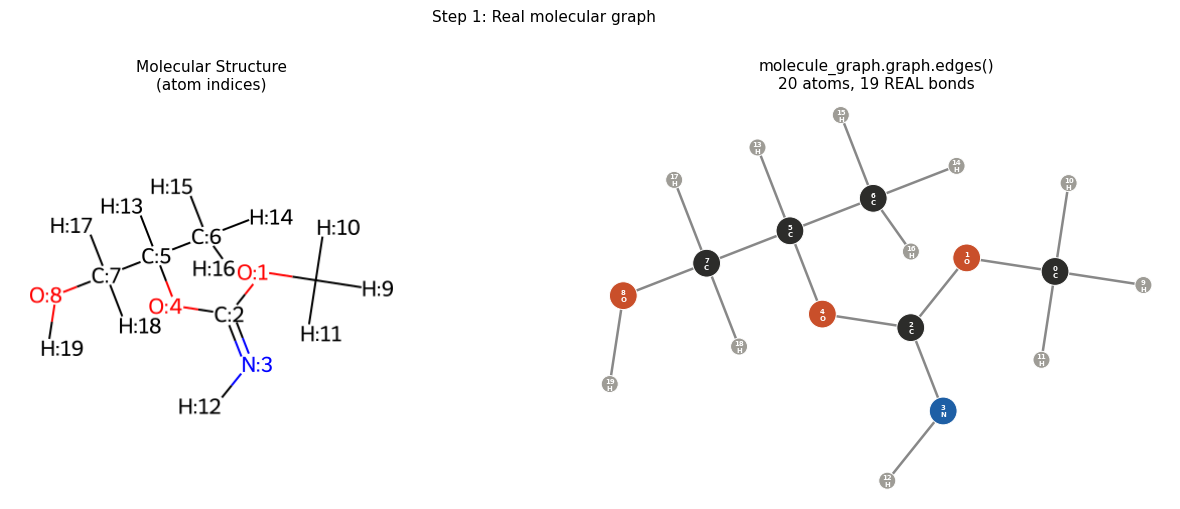

Real bonds from molecule_graph.graph.edges():
  ( 0, 1)  C-O
  ( 0, 9)  C-H
  ( 0,10)  C-H
  ( 0,11)  C-H
  ( 1, 2)  O-C
  ( 2, 3)  C-N
  ( 2, 4)  C-O
  ( 3,12)  N-H
  ( 4, 5)  O-C
  ( 5, 6)  C-C
  ( 5, 7)  C-C
  ( 5,13)  C-H
  ( 6,14)  C-H
  ( 6,15)  C-H
  ( 6,16)  C-H
  ( 7, 8)  C-O
  ( 7,17)  C-H
  ( 7,18)  C-H
  ( 8,19)  O-H


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Real molecular graph
# Left : RDKit 2D structure (MolToImage, same as GNN_representation.ipynb)
# Right: Graph drawn at RDKit 2D coordinates — graph layout = chemical structure
# ══════════════════════════════════════════════════════════════════════════════
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
import networkx as nx

pos, rdkit_mol = get_rdkit_pos(smiles, n_atoms)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RDKit structure image (with atom map numbers = indices)
draw_mol_structure(smiles, axes[0], n_atoms,
                   title="Molecular Structure\n(atom indices)")

# Right: graph at RDKit 2D coordinates
edge_colors = ["#888888"] * len(mg_edges)
draw_graph_on_rdkit_coords(
    axes[1], pos, syms, n_atoms, mg_edges,
    edge_colors=edge_colors,
    title=f"molecule_graph.graph.edges()\n{n_atoms} atoms, {len(mg_edges)} REAL bonds"
)

fig.suptitle("Step 1: Real molecular graph", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("Real bonds from molecule_graph.graph.edges():")
for i, j in mg_edges:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")


## Step 2 — The `bonds` column is NOT the molecular graph

The config uses `bond_key='bonds'`, which points to the `bonds` column in the PKL. This column contains the **QTAIM BCP list** — not the full covalent bonds.

Some real bonds are absent. Some phantom non-covalent BCPs are present.

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — What is in the "bonds" column?
#
# In HeteroCompleteGraphFromMolWrapper the graph is built using:
#   bond_key = "bonds"   (config["dataset"]["bond_key"])
#
# This means the BOND NODES are created from row["bonds"], NOT from
# molecule_graph.graph.edges(). Let us see what "bonds" actually contains.
# ══════════════════════════════════════════════════════════════════════════════
mg  = set(mg_edges)
bnd = set(bonds_col)

only_mg   = sorted(mg  - bnd)   # real bonds NOT in the graph
only_bond = sorted(bnd - mg)    # graph bonds NOT real covalent bonds
in_both   = sorted(mg  & bnd)

print("Comparing molecule_graph.edges() vs PKL 'bonds' column:")
print(f"  In both (real & in graph)        : {len(in_both)}")
print(f"  Only in mol_graph (MISSING)      : {len(only_mg)}  ← not included as bond nodes!")
print(f"  Only in bonds col (PHANTOM)      : {len(only_bond)}  ← bond nodes for non-real pairs!")
print()
print(f"Real bonds that ARE bond nodes ({len(in_both)}):")
for i,j in in_both:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")
print(f"\nReal bonds MISSING from graph ({len(only_mg)}) — NO bond node created:")
for i,j in only_mg:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}  ← this bond has NO node in the graph")
print(f"\nPHANTOM bond nodes ({len(only_bond)}) — not real covalent bonds:")
for i,j in only_bond:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}  ← QTAIM BCP, not a covalent bond")


Comparing molecule_graph.edges() vs PKL 'bonds' column:
  In both (real & in graph)        : 10
  Only in mol_graph (MISSING)      : 9  ← not included as bond nodes!
  Only in bonds col (PHANTOM)      : 5  ← bond nodes for non-real pairs!

Real bonds that ARE bond nodes (10):
  ( 0, 1)  C-O
  ( 0,11)  C-H
  ( 1, 2)  O-C
  ( 2, 3)  C-N
  ( 2, 4)  C-O
  ( 3,12)  N-H
  ( 6,14)  C-H
  ( 7, 8)  C-O
  ( 7,18)  C-H
  ( 8,19)  O-H

Real bonds MISSING from graph (9) — NO bond node created:
  ( 0, 9)  C-H  ← this bond has NO node in the graph
  ( 0,10)  C-H  ← this bond has NO node in the graph
  ( 4, 5)  O-C  ← this bond has NO node in the graph
  ( 5, 6)  C-C  ← this bond has NO node in the graph
  ( 5, 7)  C-C  ← this bond has NO node in the graph
  ( 5,13)  C-H  ← this bond has NO node in the graph
  ( 6,15)  C-H  ← this bond has NO node in the graph
  ( 6,16)  C-H  ← this bond has NO node in the graph
  ( 7,17)  C-H  ← this bond has NO node in the graph

PHANTOM bond nodes (5) — not real co

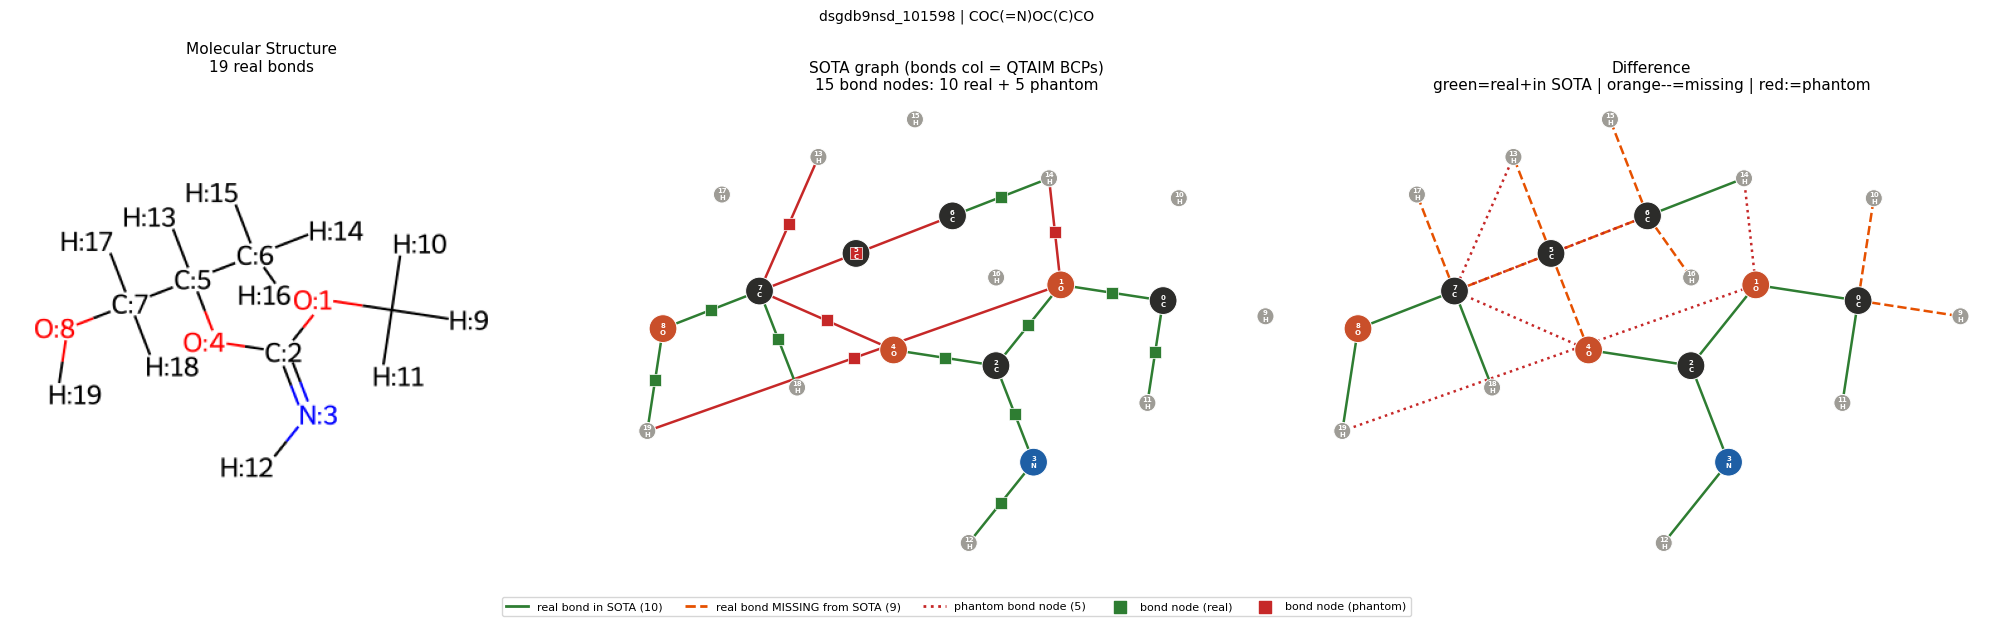

In [12]:
# ── Visualise: real vs SOTA vs difference ────────────────────────────────────
pos, _ = get_rdkit_pos(smiles, n_atoms)
mg   = set(mg_edges); bnd = set(bonds_col)
in_both   = mg & bnd
only_mg   = mg - bnd     # real bonds MISSING from SOTA
only_bond = bnd - mg     # PHANTOM bond nodes

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: full molecular graph
draw_mol_structure(smiles, axes[0], n_atoms,
                   title=f"Molecular Structure\n{len(mg)} real bonds")

# Panel 2: SOTA graph (bonds col = QTAIM topology)
all_sota_edges  = sorted(bonds_col)
sota_colors = ["#2E7D32" if e in mg else "#C62828" for e in all_sota_edges]
sota_styles = ["-"] * len(all_sota_edges)
sota_bond_nodes = [(e, "#2E7D32" if e in mg else "#C62828", "s") for e in all_sota_edges]
draw_graph_on_rdkit_coords(
    axes[1], pos, syms, n_atoms, all_sota_edges,
    edge_colors=sota_colors, edge_styles=sota_styles,
    bond_nodes=sota_bond_nodes,
    title=f"SOTA graph (bonds col = QTAIM BCPs)\n"
          f"{len(bonds_col)} bond nodes: {len(in_both)} real + {len(only_bond)} phantom"
)

# Panel 3: difference map
all_diff_edges  = sorted(in_both) + sorted(only_mg) + sorted(only_bond)
diff_colors = (["#2E7D32"]*len(in_both) +
               ["#E65100"]*len(only_mg) +
               ["#C62828"]*len(only_bond))
diff_styles = (["-"]*len(in_both) +
               ["--"]*len(only_mg) +
               [":"]*len(only_bond))
draw_graph_on_rdkit_coords(
    axes[2], pos, syms, n_atoms, all_diff_edges,
    edge_colors=diff_colors, edge_styles=diff_styles,
    title=f"Difference\ngreen=real+in SOTA | orange--=missing | red:=phantom"
)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
leg = [
    Line2D([0],[0], color="#2E7D32", lw=2,        label=f"real bond in SOTA ({len(in_both)})"),
    Line2D([0],[0], color="#E65100", lw=2, ls="--",label=f"real bond MISSING from SOTA ({len(only_mg)})"),
    Line2D([0],[0], color="#C62828", lw=2, ls=":", label=f"phantom bond node ({len(only_bond)})"),
    plt.scatter([],[],marker="s", c="#2E7D32", s=80, label="bond node (real)"),
    plt.scatter([],[],marker="s", c="#C62828", s=80, label="bond node (phantom)"),
]
fig.legend(handles=leg, loc="lower center", ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f"{MOL_ID} | {smiles}", fontsize=10)
plt.tight_layout()
plt.show()


## Step 3 — HeteroData construction

Tracing exactly how `HeteroCompleteGraphFromMolWrapper` builds the graph from the `bonds` column.

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — How this graph is physically constructed
#
# HeteroCompleteGraphFromMolWrapper with bond_key="bonds":
#   for each bond in row["bonds"]:
#       create a bond NODE
#       add edges: atom_i → bond_node, atom_j → bond_node (and reverse)
#   NOT using molecule_graph.graph.edges() for bond nodes
#
# Node types: atom (N), bond (B), global (1)
# Edge types:  atom→bond (a2b), bond→atom (b2a),
#              atom→global (a2g), global→atom (g2a),
#              bond→global (b2g), global→bond (g2b),
#              self-loops on atom and bond
# ══════════════════════════════════════════════════════════════════════════════

B = len(bonds_col)   # number of bond nodes (from "bonds" col, NOT mol_graph)
N = n_atoms

a2b_src, a2b_dst = [], []
b2a_src, b2a_dst = [], []
for bond_idx, (i,j) in enumerate(bonds_col):
    a2b_src += [i, j];          a2b_dst += [bond_idx, bond_idx]
    b2a_src += [bond_idx]*2;    b2a_dst += [i, j]

a2g_src = list(range(N)); a2g_dst = [0]*N
b2g_src = list(range(B)); b2g_dst = [0]*B

print("SOTA HeteroData graph tensors:")
print(f"  atom nodes  : {N}")
print(f"  bond nodes  : {B}  (from bonds col — QTAIM BCPs)")
print(f"  global nodes: 1")
print()
print(f"  (atom,a2b,bond)   edge_index shape: [2, {len(a2b_src)}]")
print(f"    src (atom idx): {a2b_src}")
print(f"    dst (bond idx): {a2b_dst}")
print()
print(f"  (bond,b2a,atom)   edge_index shape: [2, {len(b2a_src)}]")
print(f"    src (bond idx): {b2a_src}")
print(f"    dst (atom idx): {b2a_dst}")
print()
print(f"  (atom,a2g,global) src={a2g_src}, dst={a2g_dst}")
print(f"  (bond,b2g,global) src={b2g_src}, dst={b2g_dst}")
print()
print("Bond node table (what each bond node represents):")
for k,(i,j) in enumerate(bonds_col):
    is_real = (i,j) in set(mg_edges)
    tag = "✓ real bond" if is_real else "✗ PHANTOM (not a covalent bond)"
    print(f"  bond_node {k:2d}  atoms ({i:2d},{j:2d})  {syms[i]}-{syms[j]}  {tag}")


SOTA HeteroData graph tensors:
  atom nodes  : 20
  bond nodes  : 15  (from bonds col — QTAIM BCPs)
  global nodes: 1

  (atom,a2b,bond)   edge_index shape: [2, 30]
    src (atom idx): [0, 1, 0, 11, 1, 2, 1, 14, 1, 19, 2, 3, 2, 4, 3, 12, 4, 7, 6, 7, 6, 14, 7, 8, 7, 13, 7, 18, 8, 19]
    dst (bond idx): [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14]

  (bond,b2a,atom)   edge_index shape: [2, 30]
    src (bond idx): [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14]
    dst (atom idx): [0, 1, 0, 11, 1, 2, 1, 14, 1, 19, 2, 3, 2, 4, 3, 12, 4, 7, 6, 7, 6, 14, 7, 8, 7, 13, 7, 18, 8, 19]

  (atom,a2g,global) src=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dst=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  (bond,b2g,global) src=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], dst=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Bond node table (wh

## Step 4 — Feature vectors per experiment

All three experiments (topo, topo_elf, topo_qtaim) use the same QTAIM topology. Only the feature values on bond nodes differ.

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Feature vectors on bond nodes (what changes between experiments)
#
# Exp A topo:       bond.feat = [metal_bond, ring_incl, ring_3..7]    = 7
# Exp B topo_elf:   bond.feat = [7 topo + 5 ELF]                     = 12
# Exp C topo_qtaim: bond.feat = [7 topo + 19 QTAIM]                  = 26
#
# The 19 QTAIM features come from extra_feat_bond_* columns.
# The lookup works as: position k in those arrays corresponds to bond qtaim_idx[k]
# ══════════════════════════════════════════════════════════════════════════════

# Build QTAIM feature lookup: (i,j) → np.array(19)
qtaim_pairs = _parse_bonds(sota_row["extra_feat_bond_indices_qtaim"])
feat_arrays  = {c: _parse_array(sota_row[c]) for c in BOND_QTAIM_COLS}
feat_lookup  = {}
for k,(i,j) in enumerate(qtaim_pairs):
    key = (min(i,j),max(i,j))
    feat_lookup[key] = np.array([
        feat_arrays[c][k] if k<len(feat_arrays[c]) else 0. for c in BOND_QTAIM_COLS])

print("Exp C (topo+QTAIM) — bond.feat [26] for each bond node:")
print(f"  Columns 0-6  : topology  [metal_bond, ring_incl, ring_3, ring_4, ring_5, ring_6, ring_7]")
print(f"  Columns 7-25 : QTAIM     [{', '.join([c.replace('extra_feat_bond_','') for c in BOND_QTAIM_COLS[:3]])}...]")
print()
for k,(i,j) in enumerate(bonds_col):
    is_real = (i,j) in set(mg_edges)
    has_q   = (i,j) in feat_lookup
    tag     = ("✓ real" if is_real else "✗ phantom") + ("  has QTAIM" if has_q else "  zeros(19)")
    f = feat_lookup.get((i,j), np.zeros(19))
    print(f"  bond_node {k:2d} ({i},{j}) {syms[i]}-{syms[j]}  {tag}")
    if has_q:
        print(f"    QTAIM feat[0:3] = {[round(v,5) for v in f[:3]]}")
    else:
        print(f"    QTAIM feat[0:3] = [0.0, 0.0, 0.0]  ← no BCP found for this pair")


Exp C (topo+QTAIM) — bond.feat [26] for each bond node:
  Columns 0-6  : topology  [metal_bond, ring_incl, ring_3, ring_4, ring_5, ring_6, ring_7]
  Columns 7-25 : QTAIM     [Hamiltonian_K, e_density, lap_e_density...]

  bond_node  0 (0,1) C-O  ✓ real  has QTAIM
    QTAIM feat[0:3] = [np.float64(0.31851), np.float64(-0.31851), np.float64(-0.28505)]
  bond_node  1 (0,11) C-H  ✓ real  has QTAIM
    QTAIM feat[0:3] = [np.float64(0.3098), np.float64(-0.3098), np.float64(-1.09844)]
  bond_node  2 (1,2) O-C  ✓ real  has QTAIM
    QTAIM feat[0:3] = [np.float64(0.45997), np.float64(-0.45997), np.float64(-0.42044)]
  bond_node  3 (1,14) O-H  ✗ phantom  has QTAIM
    QTAIM feat[0:3] = [np.float64(-0.00128), np.float64(0.00128), np.float64(0.04013)]
  bond_node  4 (1,19) O-H  ✗ phantom  has QTAIM
    QTAIM feat[0:3] = [np.float64(-0.0006), np.float64(0.0006), np.float64(0.09028)]
  bond_node  5 (2,3) C-N  ✓ real  has QTAIM
    QTAIM feat[0:3] = [np.float64(0.7186), np.float64(-0.7186), np.float6

## Step 5 — Full comparison

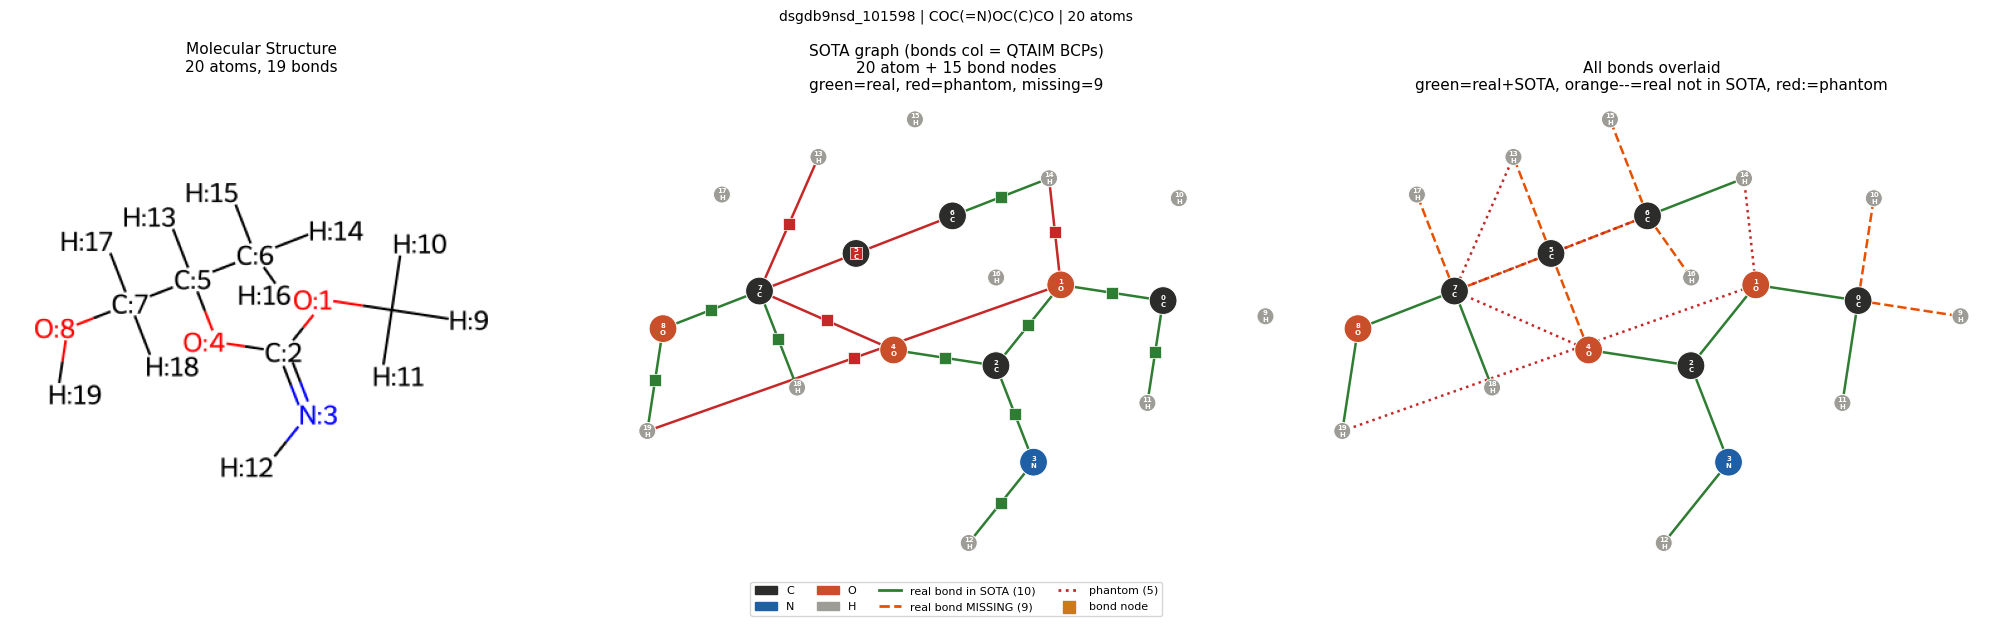

In [15]:
# ── Full comparison: mol_graph vs SOTA graph side by side ─────────────────────
pos, _ = get_rdkit_pos(smiles, n_atoms)
mg   = set(mg_edges); bnd = set(bonds_col)
in_both = mg & bnd; only_mg = mg-bnd; only_bond = bnd-mg

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: RDKit structure
draw_mol_structure(smiles, axes[0], n_atoms,
                   title=f"Molecular Structure\n{n_atoms} atoms, {len(mg)} bonds")

# Panel 2: SOTA graph with bond nodes at midpoints
sota_edges  = sorted(bonds_col)
sota_colors = ["#2E7D32" if e in mg else "#C62828" for e in sota_edges]
sota_bnodes = [(e, "#2E7D32" if e in mg else "#C62828", "s") for e in sota_edges]
draw_graph_on_rdkit_coords(
    axes[1], pos, syms, n_atoms, sota_edges,
    edge_colors=sota_colors,
    bond_nodes=sota_bnodes,
    title=f"SOTA graph (bonds col = QTAIM BCPs)\n"
          f"{n_atoms} atom + {len(sota_edges)} bond nodes\n"
          f"green=real, red=phantom, missing={len(only_mg)}"
)

# Panel 3: both real bonds AND SOTA graph overlaid
all_e  = sorted(in_both) + sorted(only_mg) + sorted(only_bond)
all_c  = (["#2E7D32"]*len(in_both) +
          ["#E65100"]*len(only_mg) +
          ["#C62828"]*len(only_bond))
all_ls = ["-"]*len(in_both) + ["--"]*len(only_mg) + [":"]*len(only_bond)
draw_graph_on_rdkit_coords(
    axes[2], pos, syms, n_atoms, all_e,
    edge_colors=all_c, edge_styles=all_ls,
    title=f"All bonds overlaid\ngreen=real+SOTA, orange--=real not in SOTA, red:=phantom"
)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
leg = [
    mpatches.Patch(color=ATOM_COLOR["C"], label="C"),
    mpatches.Patch(color=ATOM_COLOR["N"], label="N"),
    mpatches.Patch(color=ATOM_COLOR["O"], label="O"),
    mpatches.Patch(color=ATOM_COLOR["H"], label="H"),
    Line2D([0],[0], color="#2E7D32", lw=2,         label=f"real bond in SOTA ({len(in_both)})"),
    Line2D([0],[0], color="#E65100", lw=2, ls="--", label=f"real bond MISSING ({len(only_mg)})"),
    Line2D([0],[0], color="#C62828", lw=2, ls=":",  label=f"phantom ({len(only_bond)})"),
    plt.scatter([],[],marker="s", c="#C97B1A", s=80, label="bond node"),
]
fig.legend(handles=leg, loc="lower center", ncol=4, fontsize=8,
           bbox_to_anchor=(0.5,-0.04))
fig.suptitle(f"{MOL_ID} | {smiles} | {n_atoms} atoms", fontsize=10)
plt.tight_layout(); plt.show()


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY: What this means
# ══════════════════════════════════════════════════════════════════════════════

mg  = set(mg_edges); bnd = set(bonds_col)

print("="*65)
print("  SUMMARY — How SOTA graph differs from real molecular graph")
print("="*65)
print()
print(f"  Real molecular bonds (molecule_graph.edges) : {len(mg)}")
print(f"  Bond nodes in SOTA graph  (bonds column)    : {len(bnd)}")
print()
print(f"  Real bonds that ARE in SOTA graph            : {len(mg & bnd)}")
print(f"  Real bonds MISSING from SOTA graph           : {len(mg-bnd)}")
print(f"    → no bond node created for these bonds")
print(f"    → atom pair has NO direct path through a bond node")
print(f"  PHANTOM bond nodes (not real covalent bonds) : {len(bnd-mg)}")
print(f"    → QTAIM non-bonded BCPs treated as bonds")
print()
print("  WHY: bond_key='bonds' in the config points to the QTAIM BCP list,")
print("  not to molecule_graph.graph.edges(). This is intentional in the")
print("  SOTA paper — the graph topology IS the QTAIM topology of ρ(r).")
print()
print("  CONSEQUENCE for Exp A/B/C:")
print("  All three experiments use this SAME QTAIM topology as the graph.")
print("  The 'bonds' column is always used for bond_key.")
print("  molecule_graph.graph.edges() is NOT used for graph construction.")
print()
print("  THIS IS WHY bonds appear 'missing':")
print("  They are missing from the QTAIM BCP list, so they have")
print("  no bond node at all — not just zeros, but literally absent.")
print()
print("  Your ELF CP graph avoids this: every real bond has a CP node")
print("  (because ELF basins are attributed to all real bond pairs),")
print("  and the graph topology comes from electron pair domains, not")
print("  from QTAIM saddle points of ρ(r).")
print("="*65)


  SUMMARY — How SOTA graph differs from real molecular graph

  Real molecular bonds (molecule_graph.edges) : 19
  Bond nodes in SOTA graph  (bonds column)    : 15

  Real bonds that ARE in SOTA graph            : 10
  Real bonds MISSING from SOTA graph           : 9
    → no bond node created for these bonds
    → atom pair has NO direct path through a bond node
  PHANTOM bond nodes (not real covalent bonds) : 5
    → QTAIM non-bonded BCPs treated as bonds

  WHY: bond_key='bonds' in the config points to the QTAIM BCP list,
  not to molecule_graph.graph.edges(). This is intentional in the
  SOTA paper — the graph topology IS the QTAIM topology of ρ(r).

  CONSEQUENCE for Exp A/B/C:
  All three experiments use this SAME QTAIM topology as the graph.
  The 'bonds' column is always used for bond_key.
  molecule_graph.graph.edges() is NOT used for graph construction.

  THIS IS WHY bonds appear 'missing':
  They are missing from the QTAIM BCP list, so they have
  no bond node at all — not 

## Step 6 — Your ELF CP graph (`build_hetero_critical_from_json`)

This graph is built from the **JSON critical points file**, not from the PKL at all.

Key facts from `hetero_utils.py`:
- **Atom nodes**: one per atom in `data["Atoms"]` → `atom.x = [z, 0, 0, 0, 0]` (5 features)
- **CP nodes**: one per critical point in `data["Critical Points"]` → `cp.x = [group_value, volume, population, charge, value]` (5 features)
- **ALL CPs** are included: bonding valence (between 2 atoms), lone-pair valence (1 atom), and core (1 atom)
- **Edges** come from the `Atom list` field of each CP → connect that CP node to each atom in its list
- Edge direction: `cp → atom` (and reverse `atom → cp` if `edge_mode="bidir"`)

**Crucially**: the graph topology (which atom pairs are connected via a CP) comes from ELF basin attribution — which basins are shared between which atoms — not from QTAIM BCPs.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — ELF CP graph construction traced from build_hetero_critical_from_json
# ══════════════════════════════════════════════════════════════════════════════

jf = f"{JSON_DIR}/integrated_aimel_{gdb_num:06d}.json"
with open(jf) as f: jdata = json.load(f)

atoms_json = jdata["Atoms"]
cps_json   = jdata["Critical Points"]

# ── Atom nodes (same as build_hetero_critical_from_json) ─────────────────────
atom_list_map = {}
atom_node_feats = []
for idx, (_, info) in enumerate(atoms_json.items()):
    z = info.get("z value", 0)
    atom_node_feats.append([z, 0, 0, 0, 0])
    atom_list_map[str(info.get("Atom list","")).strip()] = idx

# ── CP nodes (ALL CPs — bonding, lone pair, core) ────────────────────────────
cp_keys = sorted(cps_json.keys())
cp_node_feats = []
cp_metadata   = []   # for display
for k in cp_keys:
    cp = cps_json[k]
    group       = cp.get("group", 0)
    group_value = 0 if group==0 else -3
    volume      = cp.get("volume", 0)
    population  = cp.get("population", 0)
    charge      = cp.get("charge", 0)
    value       = cp.get("value", 0)
    cp_node_feats.append([group_value, volume, population, charge, value])

    # parse atom list for edge construction
    raw   = str(cp.get("Atom list","")).strip()
    items = [a.strip() for a in raw.strip("()").split(",") if a.strip()]
    idxs  = [atom_list_map[a] for a in items if a in atom_list_map]
    cp_type = cp.get("Type","?")
    cp_metadata.append({"key": k, "type": cp_type, "atoms": idxs,
                         "volume": volume, "population": population,
                         "charge": charge, "eta": value, "group": group})

# ── Edges: CP → atom (from Atom list) ────────────────────────────────────────
cp_to_atom_pairs = []
for cp_idx, k in enumerate(cp_keys):
    cp = cps_json[k]
    raw   = str(cp.get("Atom list","")).strip()
    items = [a.strip() for a in raw.strip("()").split(",") if a.strip()]
    for a in items:
        ai = atom_list_map.get(a)
        if ai is not None:
            cp_to_atom_pairs.append((cp_idx, ai))

import torch
n_atoms_json = len(atoms_json)
n_cps        = len(cp_keys)

# Classify CPs
valence_bond = [m for m in cp_metadata if m["type"]=="valence" and len(m["atoms"])==2]
valence_lone = [m for m in cp_metadata if m["type"]=="valence" and len(m["atoms"])==1]
core_cps     = [m for m in cp_metadata if m["type"]=="core"]

print(f"ELF JSON: {n_atoms_json} atoms, {n_cps} total CP nodes")
print(f"  Valence bonding CPs (2 atoms)  : {len(valence_bond)}  ← connect two atoms")
print(f"  Valence lone-pair CPs (1 atom) : {len(valence_lone)}  ← connect to one atom")
print(f"  Core CPs (1 atom)              : {len(core_cps)}   ← connect to one atom")
print()
print(f"Edges: {len(cp_to_atom_pairs)} (cp→atom connections)")
print()

# Compare bonding CP atom pairs vs real bonds
mg = set(mg_edges)
elf_bond_pairs = {(min(m["atoms"][0],m["atoms"][1]),
                   max(m["atoms"][0],m["atoms"][1]))
                  for m in valence_bond}
elf_only = sorted(elf_bond_pairs - mg)
mg_only  = sorted(mg - elf_bond_pairs)
both     = sorted(elf_bond_pairs & mg)

print(f"Bonding CP pairs vs real molecular bonds:")
print(f"  In both (real & has bonding CP)          : {len(both)}")
print(f"  Real bonds with NO bonding CP (ELF miss) : {len(mg_only)}")
print(f"  Bonding CPs not in mol_graph             : {len(elf_only)}")
print()
if mg_only:
    print(f"  Real bonds without a bonding CP:")
    for i,j in mg_only:
        print(f"    ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")
if elf_only:
    print(f"  ELF bonding CPs not real bonds (non-covalent basins):")
    for i,j in elf_only:
        print(f"    ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")


ELF JSON: 20 atoms, 34 total CP nodes
  Valence bonding CPs (2 atoms)  : 19  ← connect two atoms
  Valence lone-pair CPs (1 atom) : 6  ← connect to one atom
  Core CPs (1 atom)              : 9   ← connect to one atom

Edges: 53 (cp→atom connections)

Bonding CP pairs vs real molecular bonds:
  In both (real & has bonding CP)          : 18
  Real bonds with NO bonding CP (ELF miss) : 1
  Bonding CPs not in mol_graph             : 0

  Real bonds without a bonding CP:
    ( 7, 8)  C-O


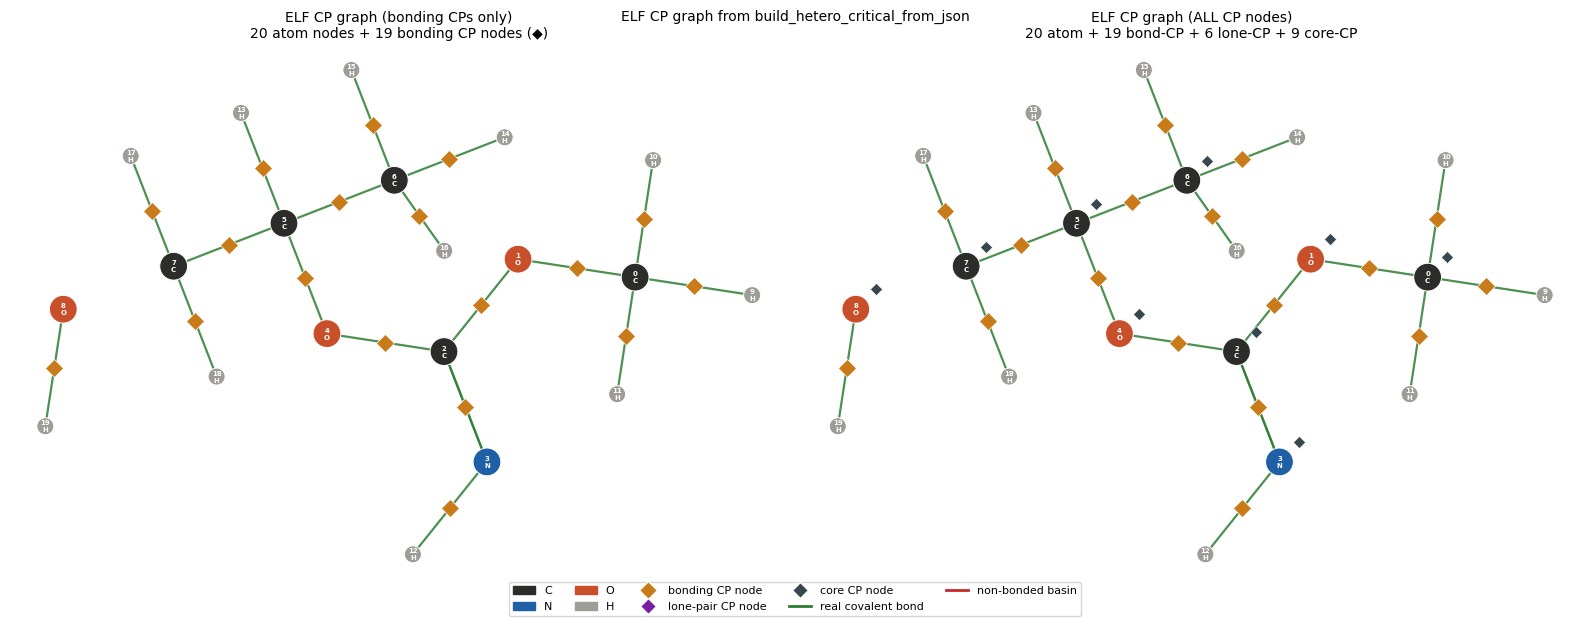

In [18]:
# ── ELF CP graph drawn at RDKit 2D coordinates ───────────────────────────────
pos, _ = get_rdkit_pos(smiles, n_atoms)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for panel_idx, ax in enumerate(axes):
    # Collect edges and bond/cp nodes
    edges_to_draw  = []
    edge_colors_td = []
    bond_nodes_td  = []
    lone_core_nds  = []

    for cp_idx, m in enumerate(cp_metadata):
        t = m["type"]; atoms = m["atoms"]
        if panel_idx == 0 and (t != "valence" or len(atoms) != 2):
            continue  # left panel: bonding CPs only

        if t == "valence" and len(atoms) == 2:
            i, j = atoms[0], atoms[1]
            real = (min(i,j),max(i,j)) in set(mg_edges)
            col = "#2E7D32" if real else "#C62828"
            edges_to_draw.append((i, j)); edge_colors_td.append(col)
            mid = ((pos[i][0]+pos[j][0])/2, (pos[i][1]+pos[j][1])/2)
            bond_nodes_td.append((mid, CP_BOND_C))
        elif len(atoms) == 1:
            i = atoms[0]
            offset = 0.25
            lone_core_nds.append(
                ((pos[i][0]+offset, pos[i][1]+offset),
                 CP_LONE_C if t=="valence" else CP_CORE_C,
                 "D"))

    # draw edges
    for (i,j), col in zip(edges_to_draw, edge_colors_td):
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                color=col, lw=1.6, zorder=1, alpha=0.85)

    # draw bond CP diamonds at midpoints
    for (mx, my), c in bond_nodes_td:
        ax.plot(mx, my, "D", color=c, ms=9, zorder=4,
                markeredgecolor="white", markeredgewidth=0.5)

    # draw lone/core CP diamonds (small offset from atom)
    if panel_idx == 1:
        for (px, py), c, mk in lone_core_nds:
            ax.plot(px, py, mk, color=c, ms=6, zorder=4,
                    markeredgecolor="white", markeredgewidth=0.4)

    # draw atom nodes
    xs = [pos[i][0] for i in range(n_atoms)]
    ys = [pos[i][1] for i in range(n_atoms)]
    node_c = [ATOM_COLOR.get(syms[i],"#888") for i in range(n_atoms)]
    node_s = [400 if syms[i]!="H" else 150 for i in range(n_atoms)]
    ax.scatter(xs, ys, c=node_c, s=node_s, zorder=3,
               edgecolors="white", linewidths=0.7)
    for i in range(n_atoms):
        ax.annotate(f"{i}\n{syms[i]}", (pos[i][0], pos[i][1]),
                    ha="center", va="center", fontsize=5,
                    color="white", fontweight="bold", zorder=5)

    ax.set_aspect("equal"); ax.axis("off")
    if panel_idx == 0:
        ax.set_title(f"ELF CP graph (bonding CPs only)\n"
                     f"{n_atoms} atom nodes + {len(valence_bond)} bonding CP nodes (◆)",
                     fontsize=10)
    else:
        ax.set_title(f"ELF CP graph (ALL CP nodes)\n"
                     f"{n_atoms} atom + {len(valence_bond)} bond-CP + "
                     f"{len(valence_lone)} lone-CP + {len(core_cps)} core-CP",
                     fontsize=10)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
leg = [mpatches.Patch(color=ATOM_COLOR["C"],label="C"),
       mpatches.Patch(color=ATOM_COLOR["N"],label="N"),
       mpatches.Patch(color=ATOM_COLOR["O"],label="O"),
       mpatches.Patch(color=ATOM_COLOR["H"],label="H"),
       Line2D([0],[0],marker="D",color="w",markerfacecolor=CP_BOND_C,ms=9,label="bonding CP node"),
       Line2D([0],[0],marker="D",color="w",markerfacecolor=CP_LONE_C,ms=8,label="lone-pair CP node"),
       Line2D([0],[0],marker="D",color="w",markerfacecolor=CP_CORE_C,ms=8,label="core CP node"),
       Line2D([0],[0],color="#2E7D32",lw=2,label="real covalent bond"),
       Line2D([0],[0],color="#C62828",lw=2,label="non-bonded basin")]
fig.legend(handles=leg, loc="lower center", ncol=5, fontsize=8,
           bbox_to_anchor=(0.5,-0.04))
fig.suptitle("ELF CP graph from build_hetero_critical_from_json", fontsize=10)
plt.tight_layout(); plt.show()


In [20]:
# ── ELF graph as PyG tensors ──────────────────────────────────────────────────
import torch

atom_x = torch.tensor(atom_node_feats, dtype=torch.float)  # [N, 5]
cp_x   = torch.tensor(cp_node_feats,   dtype=torch.float)  # [M, 5]

# Edge index (cp → atom), bidir adds reverse
cp_src = [p[0] for p in cp_to_atom_pairs]
at_dst = [p[1] for p in cp_to_atom_pairs]

ei_cp_to_atom = torch.tensor([cp_src, at_dst], dtype=torch.long)
ei_atom_to_cp = torch.tensor([at_dst, cp_src], dtype=torch.long)  # bidir

print("ELF CP HeteroData tensors (build_hetero_critical_from_json):")
print(f"  atom.x  : {list(atom_x.shape)}  [z, 0, 0, 0, 0] per atom")
print(f"  cp.x    : {list(cp_x.shape)}  [group_val, vol, pop, charge, eta] per CP")
print()
print(f"  (cp, to_atom, atom)  edge_index : [2, {len(cp_src)}]")
print(f"    src (cp idx) : {cp_src}")
print(f"    dst (atom)   : {at_dst}")
print()
print(f"  (atom, to_cp, cp)    edge_index : [2, {len(at_dst)}]  (bidir reverse)")
print()
print("CP node table (all CPs, as built by the code):")
print(f"  {'cp_idx':7}  {'type':8}  {'atoms':12}  {'group_val':10}  {'vol':7}  {'pop':7}  {'charge':8}  {'eta':7}")
print(f"  {'─'*75}")
for idx, m in enumerate(cp_metadata):
    gv = -3 if m["group"]!=0 else 0
    atoms_str = str(m["atoms"])
    print(f"  cp_{idx:3d}   {m['type']:<8}  {atoms_str:<12}  {gv:10d}  "
          f"{m['volume']:7.3f}  {m['population']:7.3f}  {m['charge']:8.3f}  {m['eta']:7.3f}")


ELF CP HeteroData tensors (build_hetero_critical_from_json):
  atom.x  : [20, 5]  [z, 0, 0, 0, 0] per atom
  cp.x    : [34, 5]  [group_val, vol, pop, charge, eta] per CP

  (cp, to_atom, atom)  edge_index : [2, 53]
    src (cp idx) : [0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 12, 12, 13, 13, 14, 14, 15, 16, 17, 18, 19, 20, 21, 21, 22, 23, 23, 24, 24, 25, 25, 26, 26, 27, 27, 28, 29, 30, 31, 32, 33]
    dst (atom)   : [2, 11, 0, 18, 7, 13, 5, 10, 0, 9, 0, 17, 7, 15, 6, 14, 6, 16, 6, 12, 3, 5, 19, 8, 5, 7, 5, 6, 3, 8, 8, 4, 1, 1, 2, 3, 7, 2, 3, 2, 1, 1, 0, 2, 4, 4, 5, 0, 6, 3, 8, 4, 1]

  (atom, to_cp, cp)    edge_index : [2, 53]  (bidir reverse)

CP node table (all CPs, as built by the code):
  cp_idx   type      atoms         group_val   vol      pop      charge    eta    
  ───────────────────────────────────────────────────────────────────────────
  cp_  0   core      [2]                    0    0.839    2.090     3.910    1.000
  cp_  1   valence   [11, 0] 

## Final comparison: all three graphs side by side

Now we can directly compare the three graph construction strategies on the same molecule with the same RDKit 2D layout.

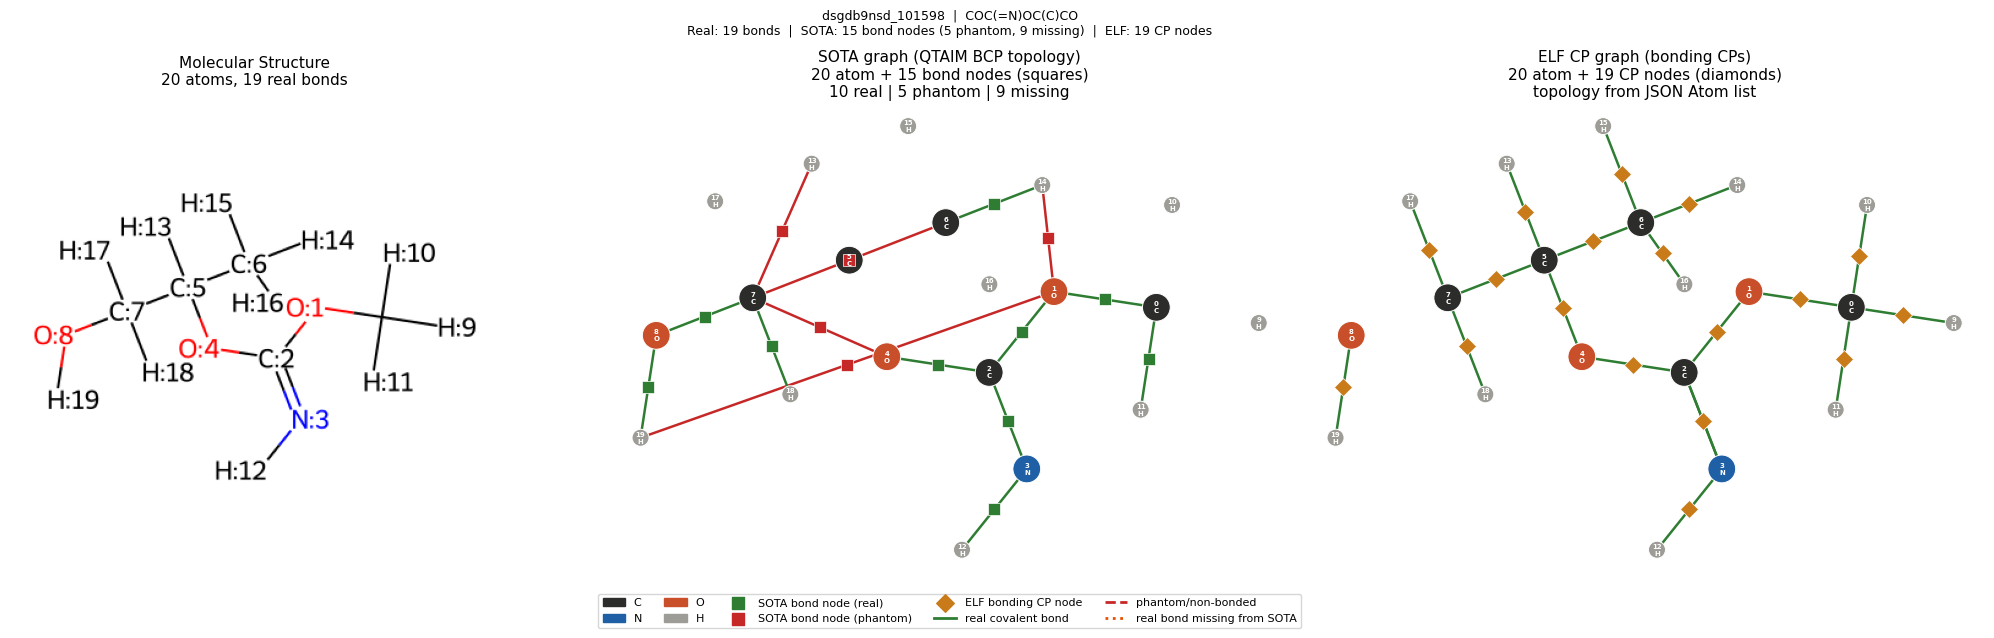

In [21]:
# ── Final 3-panel: structure + SOTA graph + ELF CP graph ────────────────────
pos, _ = get_rdkit_pos(smiles, n_atoms)
mg  = set(mg_edges); bnd = set(bonds_col)
in_both = mg & bnd; only_bond = bnd-mg; only_mg = mg-bnd

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: RDKit structure
draw_mol_structure(smiles, axes[0], n_atoms,
                   title=f"Molecular Structure\n{n_atoms} atoms, {len(mg)} real bonds")

# Panel 2: SOTA graph
sota_e  = sorted(bonds_col)
sota_c  = ["#2E7D32" if e in mg else "#C62828" for e in sota_e]
sota_bn = [(e, "#2E7D32" if e in mg else "#C62828", "s") for e in sota_e]
draw_graph_on_rdkit_coords(
    axes[1], pos, syms, n_atoms, sota_e,
    edge_colors=sota_c,
    bond_nodes=sota_bn,
    title=f"SOTA graph (QTAIM BCP topology)\n"
          f"{n_atoms} atom + {len(sota_e)} bond nodes (squares)\n"
          f"{len(in_both)} real | {len(only_bond)} phantom | {len(only_mg)} missing"
)

# Panel 3: ELF CP graph (bonding CPs only)
elf_edges = []
elf_ec    = []
elf_cps_d = []
for m in cp_metadata:
    if m["type"]=="valence" and len(m["atoms"])==2:
        i, j = m["atoms"][0], m["atoms"][1]
        real = (min(i,j),max(i,j)) in mg
        elf_edges.append((i,j))
        elf_ec.append("#2E7D32" if real else "#C62828")
        elf_cps_d.append(((i,j), CP_BOND_C, "D"))

draw_graph_on_rdkit_coords(
    axes[2], pos, syms, n_atoms, elf_edges,
    edge_colors=elf_ec,
    bond_nodes=elf_cps_d,
    title=f"ELF CP graph (bonding CPs)\n"
          f"{n_atoms} atom + {len(elf_edges)} CP nodes (diamonds)\n"
          f"topology from JSON Atom list"
)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
leg = [
    mpatches.Patch(color=ATOM_COLOR["C"],label="C"),
    mpatches.Patch(color=ATOM_COLOR["N"],label="N"),
    mpatches.Patch(color=ATOM_COLOR["O"],label="O"),
    mpatches.Patch(color=ATOM_COLOR["H"],label="H"),
    plt.scatter([],[],marker="s",c="#2E7D32",s=80,label="SOTA bond node (real)"),
    plt.scatter([],[],marker="s",c="#C62828",s=80,label="SOTA bond node (phantom)"),
    plt.scatter([],[],marker="D",c=CP_BOND_C,s=80,label="ELF bonding CP node"),
    Line2D([0],[0],color="#2E7D32",lw=2,label="real covalent bond"),
    Line2D([0],[0],color="#C62828",lw=2,ls="--",label="phantom/non-bonded"),
    Line2D([0],[0],color="#E65100",lw=2,ls=":",label=f"real bond missing from SOTA"),
]
fig.legend(handles=leg, loc="lower center", ncol=5, fontsize=8,
           bbox_to_anchor=(0.5,-0.06))
fig.suptitle(
    f"{MOL_ID}  |  {smiles}\n"
    f"Real: {len(mg)} bonds  |  "
    f"SOTA: {len(sota_e)} bond nodes ({len(only_bond)} phantom, {len(only_mg)} missing)  |  "
    f"ELF: {len(elf_edges)} CP nodes",
    fontsize=9)
plt.tight_layout(); plt.show()
